# Policy Gradients

A policy is a model that returns a probability distribution over possible actions given a current state observation. To train this model, we can run gradient ascent on the parameters with respect to the expected rewards that the model will receive.

## Formula Derivation

In order to run gradient ascent, we must find a way to compute the gradients. We can derive a usable formula through standard manipulations.

The following equation defines $J$ as the expected reward that a policy $\pi$, parameterized by $\theta$, will attain in a trajectory sampled from it.

$$
J(\theta)=\mathbb{E}[R(\tau) | \pi(\theta)] 
$$

We want to find the gradient of the expected reward function with respect to the parameters of our policy:
$$
\begin{equation}
\nabla_\theta J=\nabla_\theta \mathbb{E}[R(\tau) | \pi(\theta)]
\end{equation}
$$

### Probability of a trajectory

Expanding the expectation in equation 1, we get $\mathbb{E}[R(\tau) | \pi(\theta)]=\sum_\tau \mathbb{P}(\tau|\pi(\theta)) R(\tau)$. From this we can see that we need a formula for the probability of a trajectory under $\pi$.

The probability that a given trajectory—$\tau$, with $T$ actions—consisting of a set of states, $(s_0, s_1, ... ,s_T)$, and actions, $(a_0, a_1, ...,a_{T-1})$, occurs under a policy $\pi$ can be calculated as follows:

$$
\begin{equation}
\mathbb{P}(\tau|\pi(\theta)) = \mathbb{P}(s_0)\prod_{t=0}^{T-1} \pi_\theta(a_t|s_t) \mathbb{P}(s_{t + 1} | a_t, s_t)
\end{equation}
$$

Noticing the product, we can derive a similar expression with a sum (which simplifies gradient algebra) by taking the natural log of both sides of the equation, yielding:

$$
\log \mathbb{P}(\tau|\pi(\theta)) = \log \mathbb{P}(s_0) + \sum_{t=0}^{T-1} \log \pi_\theta(a_t|s_t) + \log \mathbb{P}(s_{t + 1} | a_t, s_t)
$$

Making the observation that the terms $\log \mathbb{P}(s_0)$ and $\log \mathbb{P}(s_{t + 1} | a_t, s_t)$ do not depend on theta, if we take the gradient of both sides with respect to $\theta$, we can get:

$$
\begin{equation}
\nabla_\theta \log \mathbb{P}(\tau|\pi(\theta)) = \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t)
\end{equation}
$$


### Log Derivative Trick

Using the chain rule, we can derive the following identity for an arbitrary differentiable multivariate function, $P$, where $\log$ denotes the natural logarithm:

$$
\nabla_\theta P(\theta) = P(\theta) \nabla_\theta \log {P(\theta)}
$$

This is true because:

$$
P(\theta) \nabla_\theta \log {P(\theta)} \\
= P(\theta) \ (\nabla_\theta {P(\theta)}) \ \cdot \ \frac{1}{P(\theta)} \\
= \nabla_\theta {P(\theta)}
$$


### Putting it all together

Revisiting equation 1, we can use the facts derived above to find a usable formula for $\nabla_\theta J(\theta)$:

$$

\begin{align}
\nabla_\theta J &= \nabla_\theta \mathbb{E}[R(\tau) | \pi(\theta)] \\
                &= \nabla_\theta \sum_\tau \mathbb{P}(\tau|\pi(\theta)) R(\tau) \\
                &= \sum_\tau \nabla_\theta \mathbb{P}(\tau|\pi(\theta)) R(\tau) \\
                &= \sum_\tau \mathbb{P}(\tau|\pi(\theta)) \ \nabla_\theta [\log \mathbb{P}(\tau|\pi(\theta))] \ R(\tau) \\
                &= \sum_\tau \mathbb{P}(\tau|\pi(\theta)) \ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) \ R(\tau) \\
                &= \mathbb{E}[ \ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) \ R(\tau) \ ]
\end{align}
$$

With this formula, we can approximate $\nabla_\theta J$ by sampling from our policy at each iteration. We can now implement our first model trained from policy gradients. (Note that this formula is very simple, and there are many improvements that can be made to reduce the variance of our gradient estimation.)

## Policy Gradient Implementation p.1

First, we start with some imports. For this demonstration, we use gymnasium to create the environment that our policy will make observations and take actions in.

In [59]:
# Machine learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym

import matplotlib.pyplot as plt

In [60]:

env = gym.make("CartPole-v1", render_mode="human")

observation, info = env.reset()

print(f"Starting observation: {observation}")

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episode_over = terminated or truncated

print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: [ 0.04017752  0.01024845 -0.04705387 -0.00347664]
Episode finished! Total reward: 38.0


## Model Definition


In [61]:

class CartPolePolicy(nn.Module):

    def __init__(self, input_size=4, actions=2, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.fc1 = nn.Linear(in_features=input_size, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=16)
        self.fc3 = nn.Linear(in_features=16, out_features=16)
        self.fc4 = nn.Linear(in_features=16, out_features=2)
    
    def forward(self, x):
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


## Trainer Class

Here we define a class that contains our training pipeline. To train our policy, we sample batches trajectories from our policy and apply the policy gradient theorem.

We use a modified formulation where the gradient is weighted only by future rewards to reduce variance.

In [62]:

class CartPoleTrainer:

    def __init__(self, policy, environment, device, lr=1e-3):
        
        self.policy = policy
        self.environment = environment
        self.device = device

        self.policy.to(self.device)
        self.lr = lr
        self.optimizer = optim.AdamW(self.policy.parameters(), lr=self.lr)

        
    def _get_trajectory(self, max_steps=500):

        observation, info = self.environment.reset()
        log_probabilities = []
        rewards = []
        for _ in range(max_steps):
            observation = torch.tensor(observation, dtype=torch.float32).to(self.device)
            action_probs = F.softmax(self.policy(observation), dim=-1)
            action = torch.multinomial(action_probs, 1).item()
            log_prob = torch.log(action_probs[action])

            observation, reward, terminated, truncated, info = self.environment.step(action)
            log_probabilities.append(log_prob)
            rewards.append(reward)
            if terminated or truncated:
                break
            
        return log_probabilities, rewards

    def train(self, num_episodes=1000, max_steps=500, num_epochs=10):
        
        avg_rewards = []

        for epoch in range(num_epochs):

            # create a batch of trajectories
            episode_rewards = []
            episode_log_probabilities = []
            for episode in range(num_episodes):
                log_probabilities, rewards = self._get_trajectory(max_steps)
                episode_rewards.append(rewards)
                episode_log_probabilities.append(log_probabilities)
            
            total_reward = 0.0
            # compute the policy gradient loss
            loss = torch.tensor(0.0).to(self.device)
            for log_probs, rewards in zip(episode_log_probabilities, episode_rewards):
                future_reward = 0.0
                for log_prob, reward in zip(reversed(log_probs), reversed(rewards)):
                    future_reward = reward + future_reward
                    loss -= log_prob * future_reward
                
                total_reward += sum(rewards)
            
            loss /= num_episodes
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            avg_reward = total_reward / num_episodes
            avg_rewards.append(avg_reward)
            print(f"Epoch {epoch + 1}/{num_epochs}, Average Reward: {avg_reward:.2f}")
        return avg_rewards

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CartPolePolicy()
env = gym.make("CartPole-v1", render_mode=None)
trainer = CartPoleTrainer(model, env, device)
rewards = trainer.train(num_episodes=100, num_epochs=200)

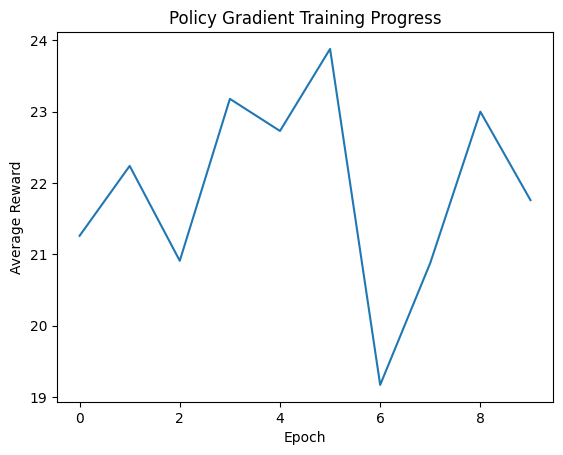

In [ ]:
plt.plot(rewards)
plt.xlabel("Epoch")
plt.ylabel("Average Reward")
plt.title("Policy Gradient Training Progress")
plt.show()

## Trained Policy Demo

In [94]:

class CartPoleDemo:

    def __init__(self, policy, environment):
        self.policy = policy
        self.environment = environment
    
    def run_episode(self, max_steps=500):
        observation, info = self.environment.reset()
        total_reward = 0.0
        for _ in range(max_steps):
            observation = torch.tensor(observation, dtype=torch.float32)
            action_probs = F.softmax(self.policy(observation), dim=-1)
            action = torch.multinomial(action_probs, 1).item()

            observation, reward, terminated, truncated, info = self.environment.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        
        self.environment.close()
        print(f"Episode finished! Total reward: {total_reward}")



In [95]:

env = gym.make("CartPole-v1", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env, "tmp", episode_trigger=lambda e: True)
demo = CartPoleDemo(model, env)
demo.run_episode()



Episode finished! Total reward: 126.0


Here is a video that shows the trained policy in action.

<video width="480" controls>
  <source src="assets/policy_gradients_demo.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

## Evaluation

In [97]:

class CartPoleRandomEval:
    def __init__(self, environment):
        self.environment = environment
    
    def evaluate(self, num_episodes=1000, max_steps=500):
        total_reward = 0.0
        for episode in range(num_episodes):
            observation, info = self.environment.reset()
            episode_reward = 0.0
            for _ in range(max_steps):
                action = self.environment.action_space.sample()
                observation, reward, terminated, truncated, info = self.environment.step(action)
                episode_reward += reward
                if terminated or truncated:
                    break
            total_reward += episode_reward
            
        avg_reward = total_reward / num_episodes
        return avg_reward

In [96]:
class CartPolePolicyEval:

    def __init__(self, policy, environment):
        self.policy = policy
        self.environment = environment
    
    def evaluate(self, num_episodes=1000, max_steps=500):
        total_reward = 0.0
        for episode in range(num_episodes):
            observation, info = self.environment.reset()
            episode_reward = 0.0
            for _ in range(max_steps):
                observation = torch.tensor(observation, dtype=torch.float32)
                action_probs = F.softmax(self.policy(observation), dim=-1)
                action = torch.multinomial(action_probs, 1).item()

                observation, reward, terminated, truncated, info = self.environment.step(action)
                episode_reward += reward
                if terminated or truncated:
                    break
            
            total_reward += episode_reward

        avg_reward = total_reward / num_episodes
        return avg_reward

In [98]:
env = gym.make("CartPole-v1", render_mode=None)
random_eval = CartPoleRandomEval(env)
random_avg_reward = random_eval.evaluate(num_episodes=1000)

policy_eval = CartPolePolicyEval(model, env)
policy_avg_reward = policy_eval.evaluate(num_episodes=1000)

print(f"Random policy average reward: {random_avg_reward:.2f}")
print(f"Trained policy average reward: {policy_avg_reward:.2f}")


Random policy average reward: 22.46
Trained policy average reward: 311.82
